# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [ ]:
import torch

from src.pca import fit_pca, transform_pca, reconstruct_pca
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List
from src.utils import DATA_PATH, RANDOM_SEED, train_val_split, df_to_np, standardize, INPUT_SIZE, analyze_cluster_homogeneity
from src.plots import plot_images, plot_class_distribution, plot_images_by_class, plot_explained_variance, plot_reconstruction_comparison, plot_clusteres_2d, plot_silhouette_comparison, plot_elbow_method, plot_cluster_composition, plot_cluster_entropy, plot_eigenvectors
from src.autoencoder import ModelConfig, compare_models, Autoencoder, prepare_autoencoder_data, train_autoencoder
from src.metrics import mse, silhouette_score
from src.kmeans import kmeans
from src.gmm import gmm

np.random.seed(RANDOM_SEED)

## 1. Inspección de los datos

**a) Implementar una función que pueda graficar un número
   arbitrario de imágenes del dataset. Mostrar un ejemplo
   de un gráfico con 15 imágenes seleccionadas de manera
  aleatoria. Esta función va a ser necesaria a lo largo
  de todo el trabajo, por lo que se deberá ir adaptando
  de acuerdo a las necesidades que vayan surgiendo.**

In [65]:
df = pd.read_csv(DATA_PATH)

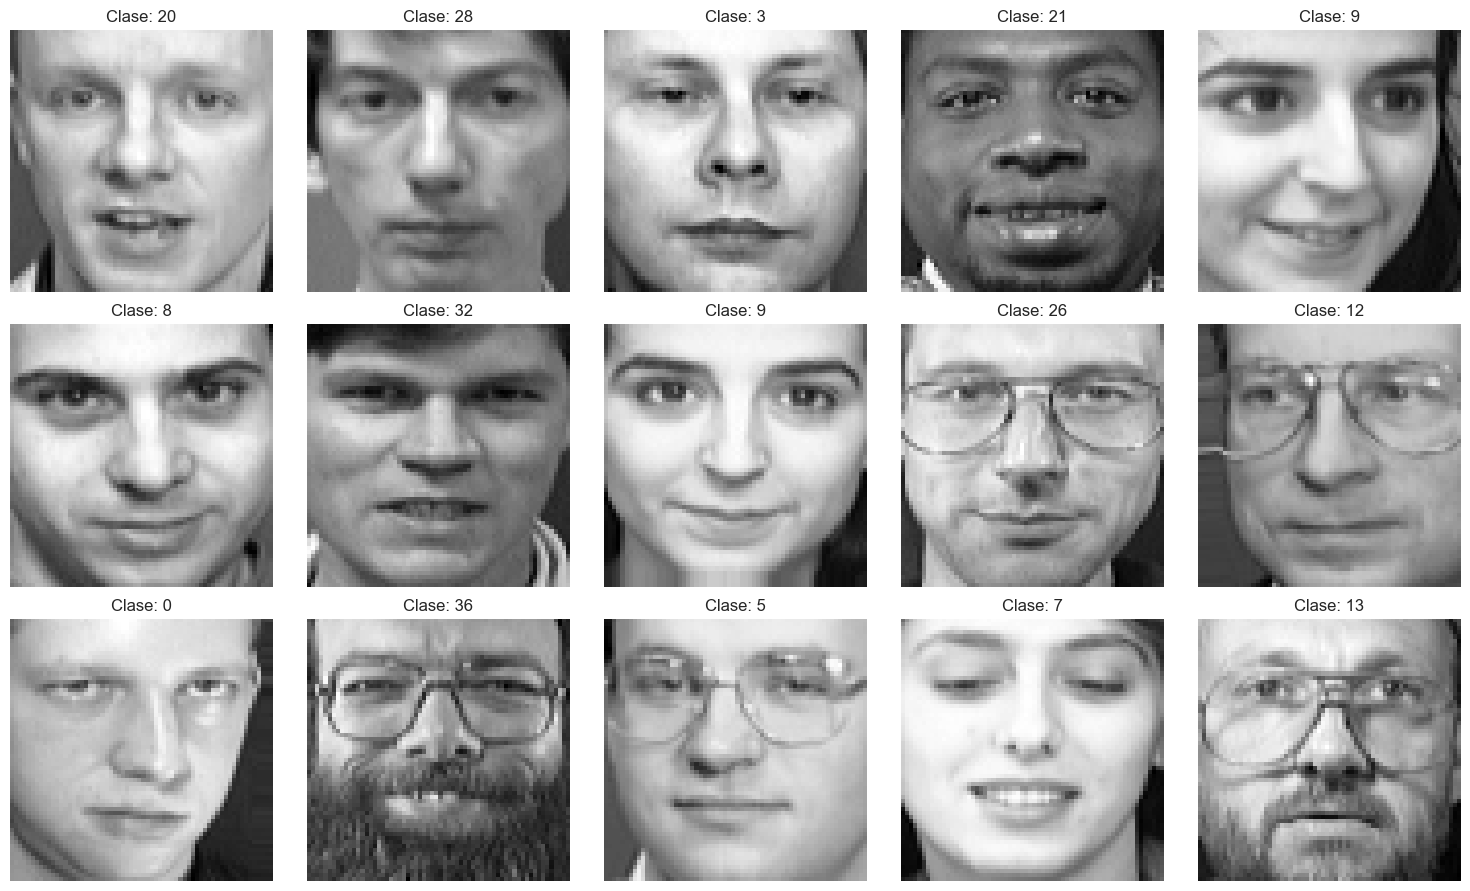

In [66]:
plot_images(df, n=15, ncols=5, filename="1_initial_faces")

**b) Realizar un analisis exploratorio enfocado en
  la distribución de clases en los datos. Para
  tener una mejor noción de la variabilidad de las
  muestras, graficar muestras agrupadas por clase,
  para al menos 5 clases.**

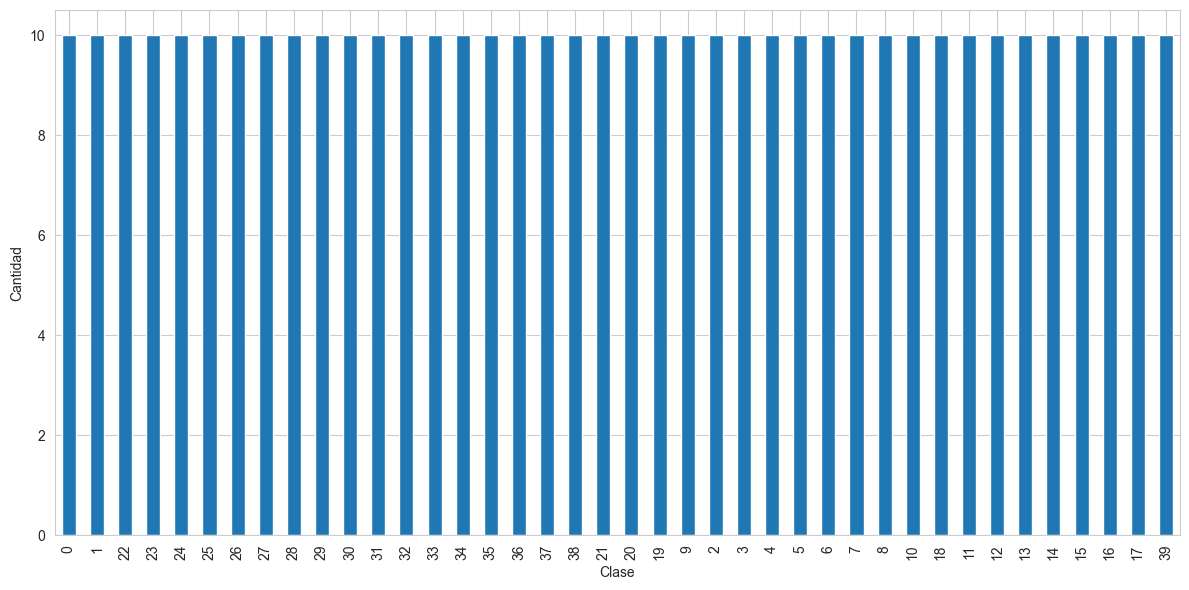

In [68]:
plot_class_distribution(df, figsize=(12,6), filename="2_class_distribution")

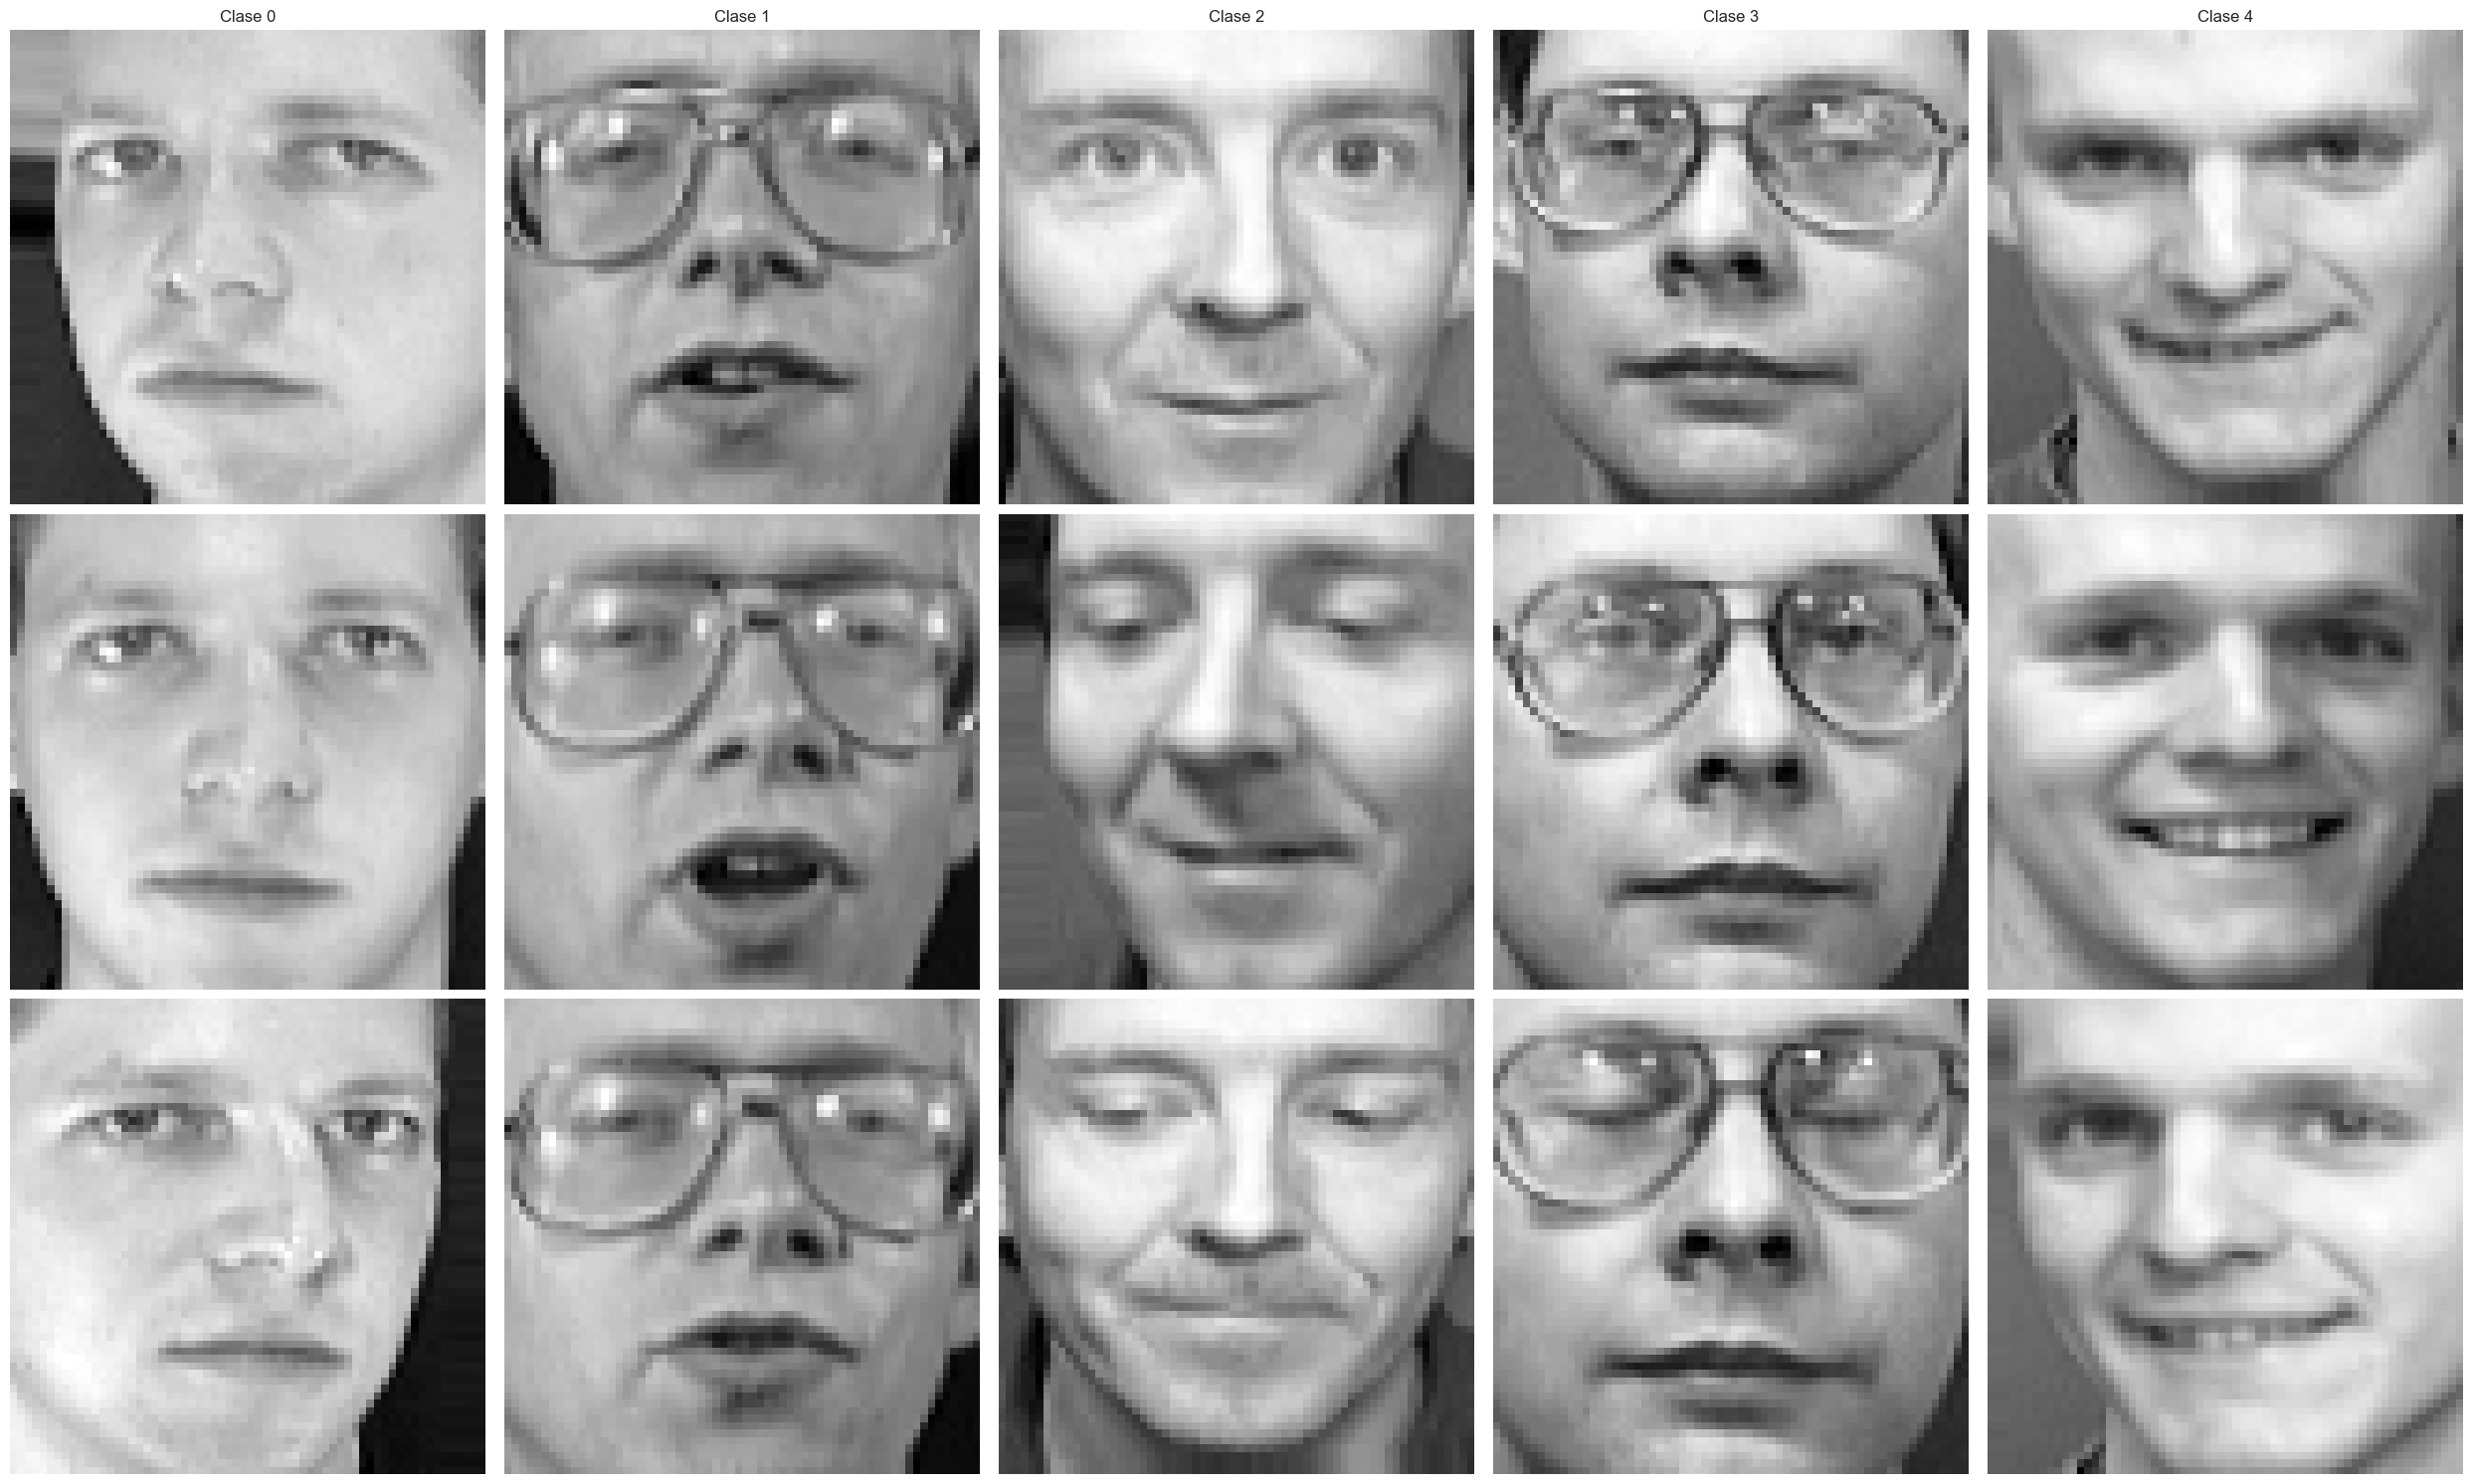

In [69]:
plot_images_by_class(df, n_classes=5, n_per_class=3, filename="3_initial_faces_by_class")

  **c) Realizar un split de datos estratificado para
  conformar un conjunto de entrenamiento y otro de
  evaluación, en donde los datos de evaluación sean
   el 20 % del total.**

In [70]:
df_train, df_val = train_val_split(df, val_size=0.2)
df_train.shape

(320, 4097)

## 2. Reducción de dimensionalidad

**a) Implementar una función para estandarizar los
  datos, y otra para realizar Principal Component
  Analysis (PCA). Estandarizar y aplicar PCA sobre
  los datos de entrenamiento. Con la transformacion
   aprendida previamente reducir la dimensionalidad
   de los datos de evaluacion.**

In [71]:
# primero convertimos a numpy
X_train, y_train = df_to_np(df_train)

# estandarizamos
X_train_std, X_train_mu, X_train_sigma = standardize(X_train)

# calculamos:
# W = autovectores como columnas
# lambdas = autovalores
# varianza explicada por cada componente principal
lambdas, W, explained_variance_ratios = fit_pca(X_train_std)

# transformamos sin reducir dimensionalidad
Z_full = transform_pca(X_train_std, W)

b) Realizar un gráfico que muestre la varianza
  explicada acumulada en función del número de
  componentes. Conservar el número de componentes
  que aseguren explicar el 90 % de la varianza de
  los datos. Utilizando la función aprendida en el
  punto 1.a), realizar un gráfico comparativo entre
   las imágenes originales y la reconstrucción
  partiendo del número de componentes determinado
  anteriormente.

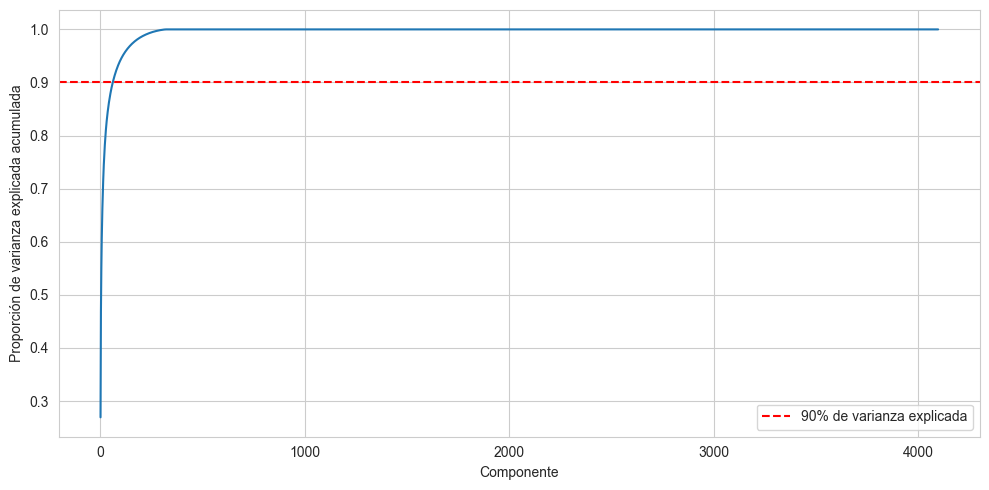

In [72]:
plot_explained_variance(explained_variance_ratios, filename="4_explained_variance")

In [73]:
threshold_component = np.argmax(np.cumsum(explained_variance_ratios) >= 0.90) + 1
print(f"Las primeras {threshold_component} componentes principales explican el 90% de la varianza")

Las primeras 61 componentes principales explican el 90% de la varianza


In [76]:
LATENT_SIZE = int(threshold_component)
Z_reduced = transform_pca(X_train_std, W, LATENT_SIZE)
X_reconstructed = reconstruct_pca(Z_reduced, W, X_train_mu, X_train_sigma, LATENT_SIZE)

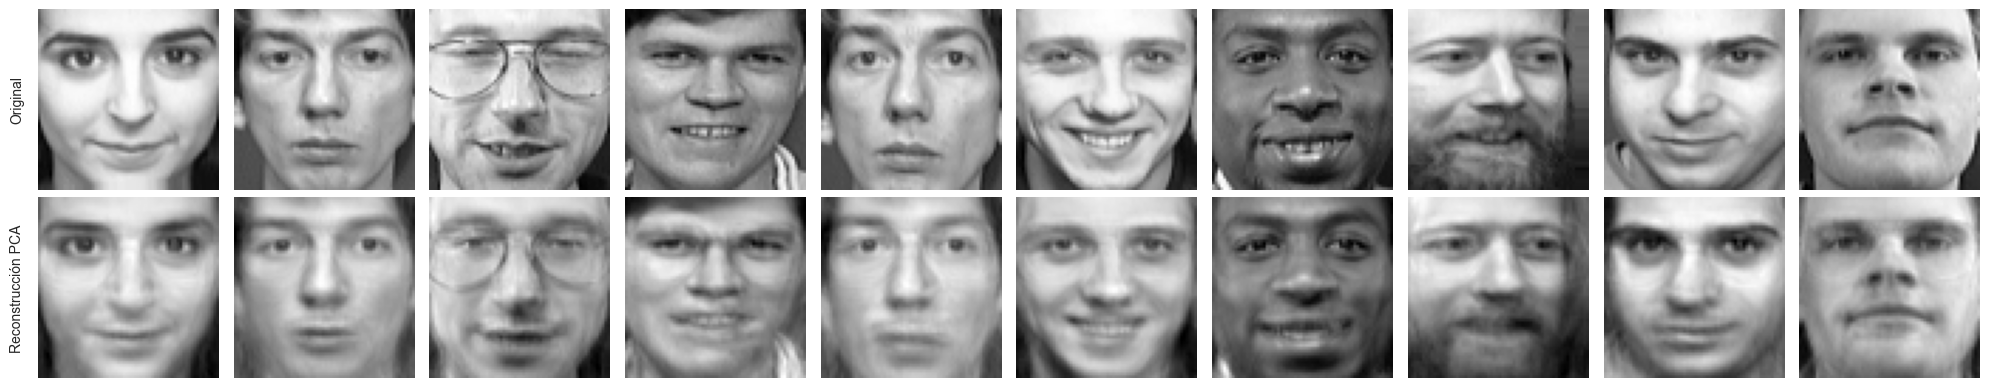

In [77]:
plot_reconstruction_comparison(X_train, X_reconstructed, n_images=10, filename="5_reconstruction_comparison")

In [78]:
mse_pca = mse(X_train, X_reconstructed)
print(f"El error de reconstrucción del PCA es: {mse_pca}")

El error de reconstrucción del PCA es: 0.00196018237003768


Bonus: Graficar los 5 autovectores principales

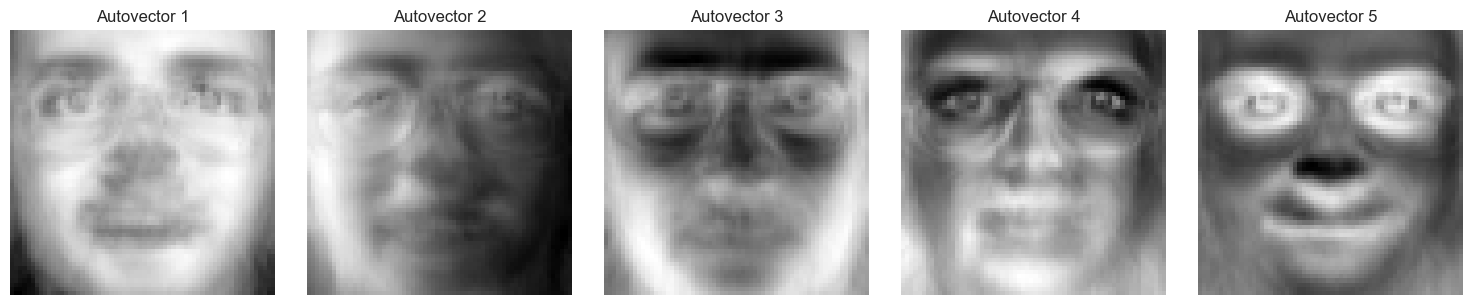

In [81]:
plot_eigenvectors(W, n_components=5, filename="6_eigenvectors")

**c) Entrenar un modelo de autoencoder
  deterministico (AE) utilizando la librería
  PyTorch para armar y entrenar las redes
  neuronales involucradas (la red de encoder y la
  de decoder). Para hacer una comparacion justa, la
   dimension latente debe ser la misma que la
  obtenida en el PCA. Recuerde dividir el conjunto
  de datos en dos subconjuntos: entrenamiento y
  validación, los mismos utilizados para el PCA. El
   subconjunto de entrenamiento se empleará para
  entrenar el AE, mientras que el de validación
  servirá para ajustar los hiperparámetros
  (regularizacion, arquitectura o lo que considere)
   y evaluar el error de reconstrucción.**

In [83]:
X_val, y_val = df_to_np(df_val)
X_val_std, _, _ = standardize(X_val, X_train_mu, X_train_sigma) # usamos los mu y sigma que obtuvimos de train

# Probamos varias arquitecturas  & dropouts
configs: List[ModelConfig] = [
    ModelConfig(
        encoder_layers=[512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512],
        dropout=0.0,
        lr=0.001,
        name="mini",
    ),
    ModelConfig(
        encoder_layers=[1024],
        latent_size=LATENT_SIZE,
        decoder_layers=[1024],
        dropout=0.0,
        lr=0.001,
        name="narrow_shallow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048],
        dropout=0.1,
        lr=0.0001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[3072],
        latent_size=LATENT_SIZE,
        decoder_layers=[3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048],
        dropout=0.2,
        lr=0.001,
        name="wide_deep_dropout_02",
    ),
    ModelConfig(
        encoder_layers=[2048, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 2048],
        dropout=0.1,
        lr=0.001,
        name="wide_shallow_dropout_01",
    ),
    ModelConfig(
        encoder_layers=[1024, 256],
        latent_size=LATENT_SIZE,
        decoder_layers=[256, 1024],
        dropout=0.0,
        lr=0.001,
        name="ultranarrow_no_dropout",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048],
        latent_size=LATENT_SIZE,
        decoder_layers=[2048, 3072],
        dropout=0.2,
        lr=0.001,
        name="ultrawide_shallow_dropout_03",
    ),
    ModelConfig(
        encoder_layers=[3072, 2048, 1024, 512],
        latent_size=LATENT_SIZE,
        decoder_layers=[512, 1024, 2048, 3072],
        dropout=0.3,
        lr=0.005,
        name="ultrawide_deep_dropout_04",

    )
]

results, best_model = compare_models(configs, X_train_std, X_val_std, epochs=500, input_size=INPUT_SIZE)

Training model: mini
Epoch 1/500, Train Loss: 1.0030, Val Loss: 1.1233
Epoch 11/500, Train Loss: 0.5627, Val Loss: 0.5541
Epoch 21/500, Train Loss: 0.4242, Val Loss: 0.4402
Epoch 31/500, Train Loss: 0.3283, Val Loss: 0.3592
Epoch 41/500, Train Loss: 0.2647, Val Loss: 0.3090
Epoch 51/500, Train Loss: 0.2198, Val Loss: 0.2780
Epoch 61/500, Train Loss: 0.1863, Val Loss: 0.2569
Epoch 71/500, Train Loss: 0.1608, Val Loss: 0.2422
Epoch 81/500, Train Loss: 0.1444, Val Loss: 0.2327
Epoch 91/500, Train Loss: 0.1262, Val Loss: 0.2248
Epoch 101/500, Train Loss: 0.1127, Val Loss: 0.2193
Epoch 111/500, Train Loss: 0.1013, Val Loss: 0.2155
Epoch 121/500, Train Loss: 0.0914, Val Loss: 0.2125
Epoch 131/500, Train Loss: 0.0841, Val Loss: 0.2129
Epoch 141/500, Train Loss: 0.0760, Val Loss: 0.2092
Epoch 151/500, Train Loss: 0.0686, Val Loss: 0.2086
Epoch 161/500, Train Loss: 0.0624, Val Loss: 0.2080
Epoch 171/500, Train Loss: 0.0571, Val Loss: 0.2080
Epoch 181/500, Train Loss: 0.0525, Val Loss: 0.2093
Ep

In [89]:
autoencoder = results[best_model]["model"]

autoencoder.eval()
with torch.no_grad():
    X_encoded_ae = autoencoder.encode(X_train_std, numpy=True)
    X_reconstructed_ae = autoencoder.reconstruct(X_encoded_ae, sigma=X_train_sigma, mu=X_train_mu, numpy=True)

    mse_ae = mse(X_train, X_reconstructed_ae)
    print(f"El error de reconstrucción del AE es: {mse_ae}")


El error de reconstrucción del AE es: 0.0006270112295617218


 **d) Una vez desarrollado el AE, compare la calidad de las imágenes reconstruidas con
  las obtenidas mediante PCA en el inciso anterior, utilizando 10 imagenes tomadas
  aleatoriamente del conjunto de validación del AE.**

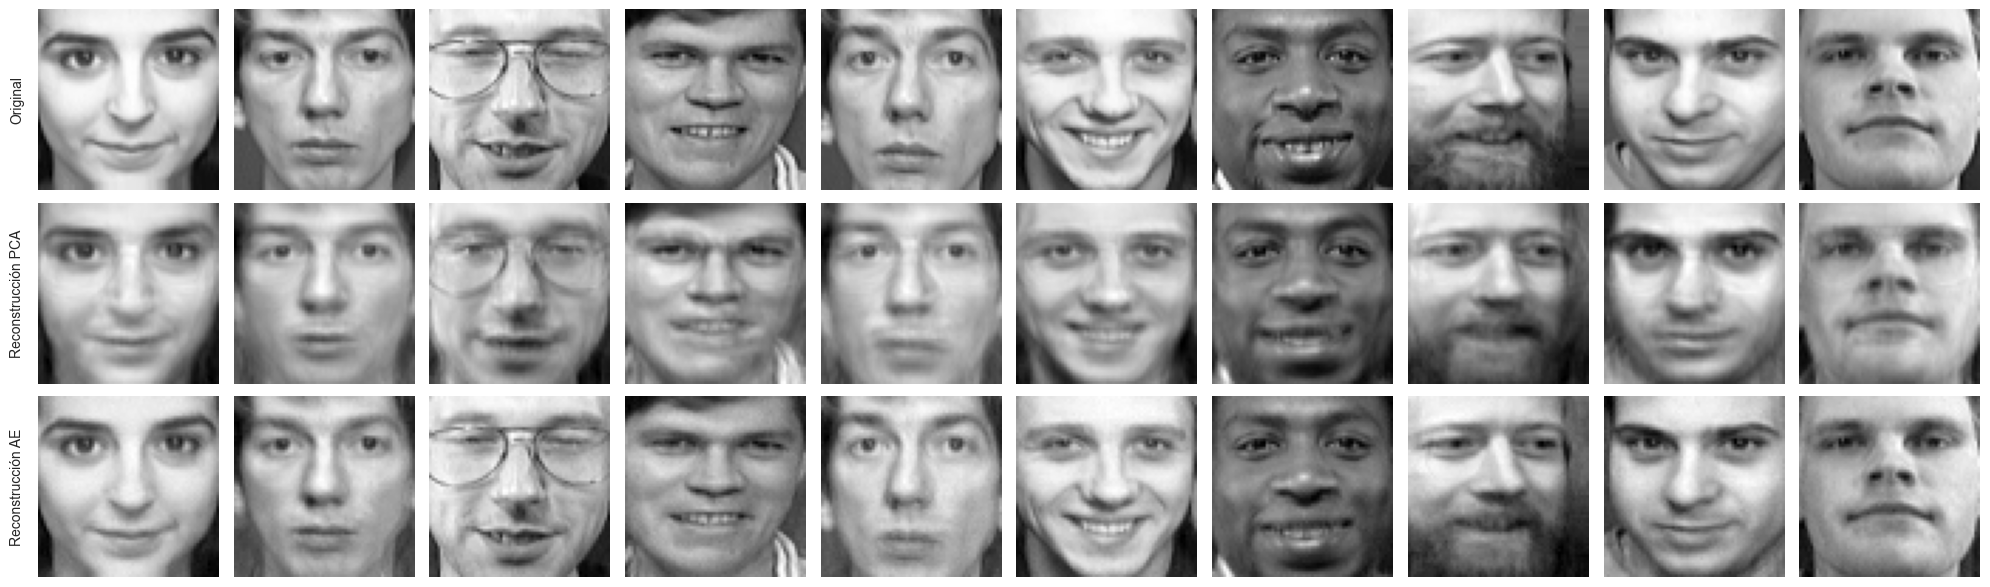

In [90]:
plot_reconstruction_comparison(X_train, X_reconstructed, X_reconstructed_ae, n_images=10, filename="7_reconstruction_comparison_ae")

 **e) Para los siguientes puntos, en lugar de trabajar con las imágenes originales vamos
  a trabajar con su versión de menor dimensionalidad en el espacio latente del PCA y AE
  obtenida en el inciso anterior para acelerar el procesamiento. Aplique la
  transformación para todos los datos, tanto de entrenamiento como de evaluación usando
  la transformacion aprendida con los datos de entrenamiento.**


In [91]:
autoencoder.eval()
with torch.no_grad():
    Z_train = autoencoder.encode(X_train_std, numpy=True)
    Z_val = autoencoder.encode(X_val_std, numpy=True)

## 3. Clustering
**a) Desarrollar una funcion que implemente el
  algoritmo k-Means. Probar con valores de K
  dentro del rango de [5, 20].**


In [92]:
kmeans_results = {}

K_RANGE = range(5, 21)

for i in K_RANGE:
    centroids, assignments, losses = kmeans(Z_train, i, max_iters=500)
    kmeans_results[i] = {
        "centroids": centroids,
        "assignments": assignments,
        "losses": losses,
        "silhouette_score": silhouette_score(Z_train, assignments),
    }

Iteration 0: loss = 1964.1545293588017
Iteration 10: loss = 1658.6877234055985
Converged at iteration 12
Iteration 0: loss = 1903.4175980070486
Iteration 10: loss = 1580.4000948812181
Converged at iteration 11
Iteration 0: loss = 1729.545777940973
Converged at iteration 10
Iteration 0: loss = 1667.0906000778846
Converged at iteration 7
Iteration 0: loss = 1606.4891762813838
Iteration 10: loss = 1402.9616583348302
Converged at iteration 13
Iteration 0: loss = 1539.0396083405317
Iteration 10: loss = 1347.5618974792424
Converged at iteration 12
Iteration 0: loss = 1486.7468246100716
Iteration 10: loss = 1324.7974556926697
Converged at iteration 12
Iteration 0: loss = 1475.5043823371407
Iteration 10: loss = 1284.9209531494967
Converged at iteration 15
Iteration 0: loss = 1457.802617865549
Iteration 10: loss = 1246.9075501183186
Converged at iteration 12
Iteration 0: loss = 1433.7379959246746
Iteration 10: loss = 1241.7205991924423
Converged at iteration 15
Iteration 0: loss = 1424.52783562

**b) Desarrollar una funcion que implemente el
  algoritmo GMM. Probar con valores de K dentro del
   rango de [5, 20]**

In [93]:
gmm_results = {}

for i in K_RANGE:
    means, covariances, priors, assignments, log_likelihoods = gmm(Z_train, i, max_iters=500, tolerance=10)
    gmm_results[i] = {
        "means": means,
        "covariances": covariances,
        "priors": priors,
        "assignments": assignments,
        "log_likelihoods": log_likelihoods,
        "silhouette_score": silhouette_score(Z_train, assignments),
    }


Iteration 0: loss = 1964.1545293588017
Iteration 10: loss = 1658.6877234055985
Converged at iteration 12
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1903.4175980070486
Iteration 10: loss = 1580.4000948812181
Converged at iteration 11
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1729.545777940973
Converged at iteration 10
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1667.0906000778846
Converged at iteration 7
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1606.4891762813838
Iteration 10: loss = 1402.9616583348302
Converged at iteration 13
Iteration 0: log likelihood = -7368.272297580908
Converged at iteration 1
Iteration 0: loss = 1539.0396083405317
Iteration 10: loss = 1347.5618974792424
Converged at iteration 12
Iteration 0: log likelihood = -7368.272297580868
Converged at iteration 1
Iteratio

**3c) Analizar el desempeño para distintos valores de
  K. Utilizar el método de ganancias decrecientes,
  junto con el método de Silhouette score. Graficar
   tanto la ganancia marginal como el valor de
  Silhouette score en función de K. ¿Qué se puede
  concluir sobre K observando estas curvas? ¿Cómo
  se relaciona el numero de K encontrado con el
  número de clases presentes en los datos?
  Justificar**

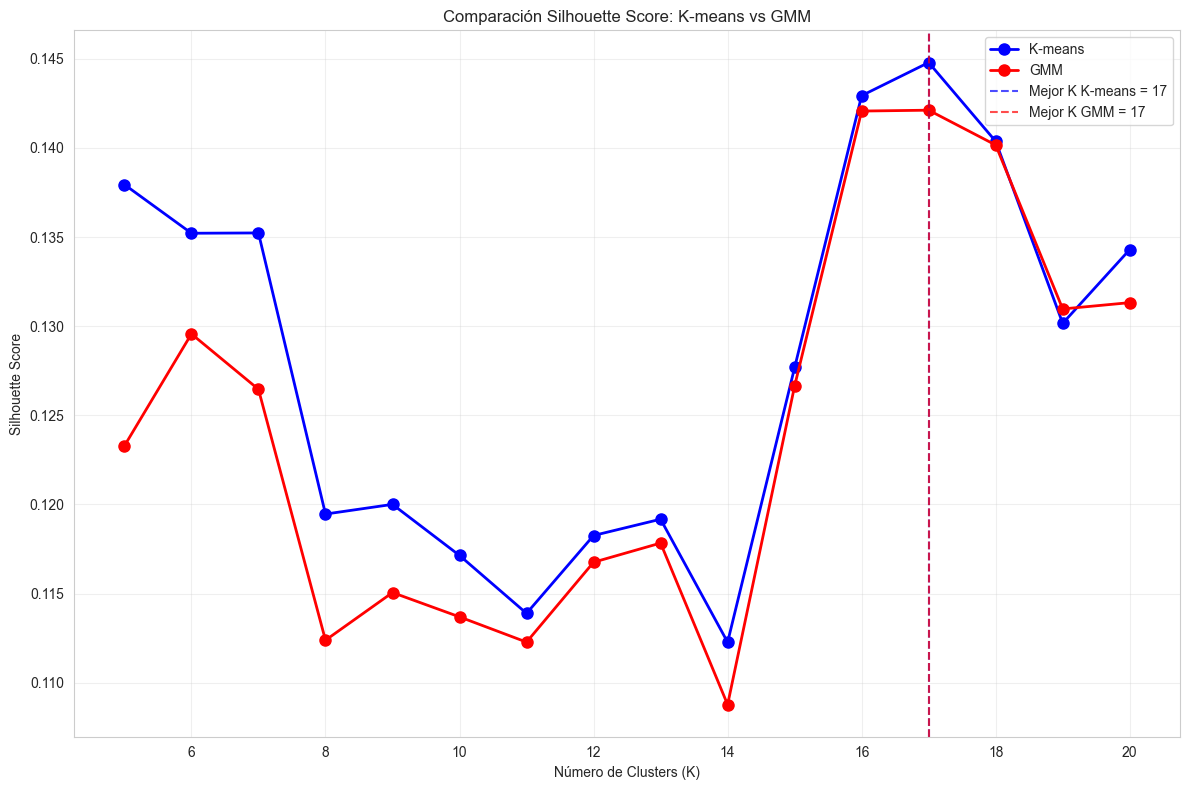

In [94]:
plot_silhouette_comparison(kmeans_results, gmm_results)

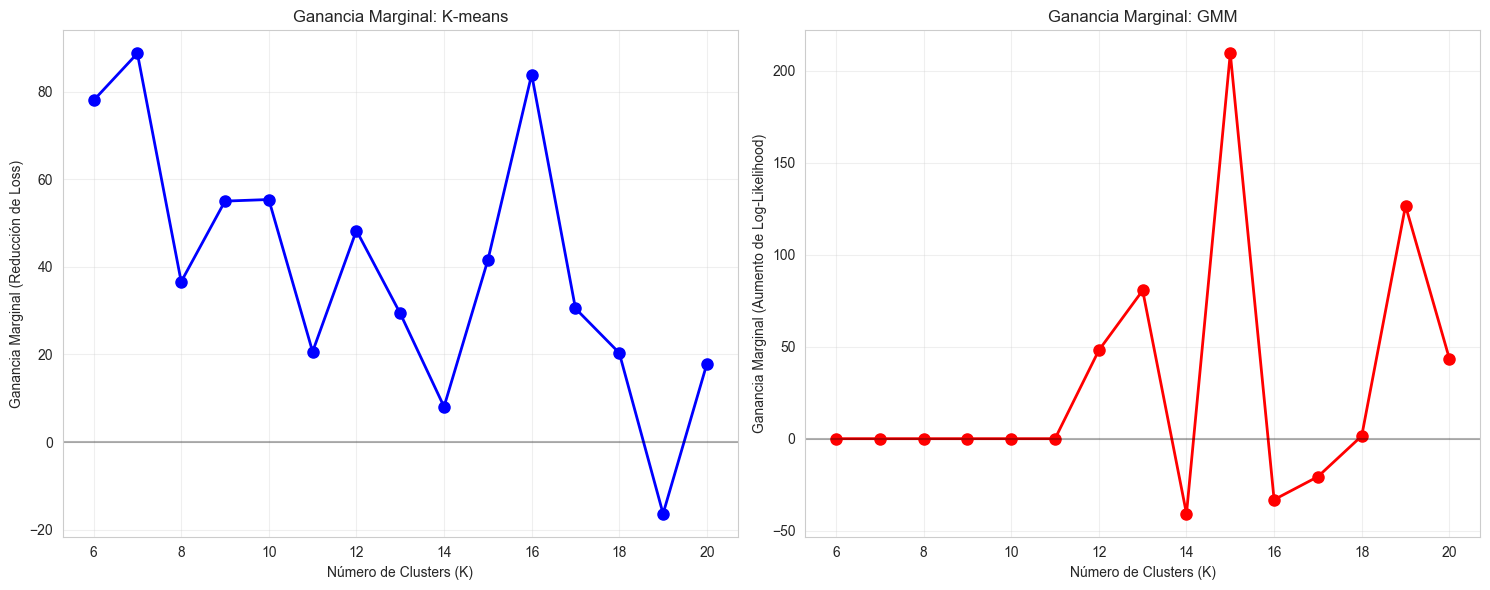

In [95]:
plot_elbow_method(kmeans_results, gmm_results, figsize=(15, 6), filename="8_elbow_method")

**d)Del mejor valor de K resultante del análisis anterior graficar las
   muestras de cada cluster en 2D utilizando la función de reduccion
  dimensional aprendida en el punto 1. ¿Qué puede decir de la calidad
   de los clusters de acuerdo a la cantidad de muestras que agrupa y
  la homogeneidad de clases en cada cluster? Realizar los
  gráficos/tablas/análisis que crea conveniente para fundamentar su
  respuesta.**

In [97]:
# Entrenamos un autoencoder con los mismos parámetros que la mejor configuración que obtuvimos, pero con dimension latente = 2
reducer_2d_config = ModelConfig(
    encoder_layers=[INPUT_SIZE, 2048],
    latent_size=2,
    decoder_layers=[2048, INPUT_SIZE],
    dropout=0.1,
    lr=0.0001,
    name="2d_reducer",
)

reducer_2d = Autoencoder(
    encoder_layers=reducer_2d_config["encoder_layers"],
    latent_size=reducer_2d_config["latent_size"],
    decoder_layers=reducer_2d_config["decoder_layers"],
    dropout=reducer_2d_config["dropout"],
)

train_loader, val_loader = prepare_autoencoder_data(X_train_std, X_val_std)
train_autoencoder(reducer_2d, train_loader, val_loader, epochs=500, lr=reducer_2d_config["lr"], patience=30, min_delta=0.0001)

Epoch 1/500, Train Loss: 1.0319, Val Loss: 1.1662
Epoch 11/500, Train Loss: 0.9989, Val Loss: 0.9892
Epoch 21/500, Train Loss: 0.6734, Val Loss: 0.6634
Epoch 31/500, Train Loss: 0.6232, Val Loss: 0.6302
Epoch 41/500, Train Loss: 0.6012, Val Loss: 0.6126
Epoch 51/500, Train Loss: 0.5928, Val Loss: 0.6054
Epoch 61/500, Train Loss: 0.5850, Val Loss: 0.6017
Epoch 71/500, Train Loss: 0.5801, Val Loss: 0.5981
Epoch 81/500, Train Loss: 0.5754, Val Loss: 0.5953
Epoch 91/500, Train Loss: 0.5713, Val Loss: 0.5930
Epoch 101/500, Train Loss: 0.5673, Val Loss: 0.5913
Epoch 111/500, Train Loss: 0.5634, Val Loss: 0.5892
Epoch 121/500, Train Loss: 0.5593, Val Loss: 0.5874
Epoch 131/500, Train Loss: 0.5552, Val Loss: 0.5856
Epoch 141/500, Train Loss: 0.5509, Val Loss: 0.5841
Epoch 151/500, Train Loss: 0.5465, Val Loss: 0.5828
Epoch 161/500, Train Loss: 0.5420, Val Loss: 0.5819
Epoch 171/500, Train Loss: 0.5373, Val Loss: 0.5813
Epoch 181/500, Train Loss: 0.5326, Val Loss: 0.5810
Epoch 191/500, Train Lo

([1.0318665504455566,
  1.1518644094467163,
  1.0233410596847534,
  1.051801085472107,
  1.073891043663025,
  1.040309190750122,
  1.0076377391815186,
  1.0011235475540161,
  1.0082736015319824,
  1.0100247859954834,
  0.9988710284233093,
  0.9745516777038574,
  0.9419509172439575,
  0.9061874151229858,
  0.8698616027832031,
  0.8337457776069641,
  0.796906590461731,
  0.7597061395645142,
  0.7258762121200562,
  0.6974541544914246,
  0.6733804941177368,
  0.6550637483596802,
  0.6445478200912476,
  0.63974928855896,
  0.6374342441558838,
  0.6360152959823608,
  0.6339110136032104,
  0.6307938098907471,
  0.627673864364624,
  0.6251261830329895,
  0.623160719871521,
  0.6200686097145081,
  0.6154729127883911,
  0.6121102571487427,
  0.6105574369430542,
  0.6090841293334961,
  0.6069520711898804,
  0.6042311787605286,
  0.6025494337081909,
  0.6019862294197083,
  0.6012104153633118,
  0.6000279188156128,
  0.5997799038887024,
  0.6008227467536926,
  0.5988932251930237,
  0.59559059143066

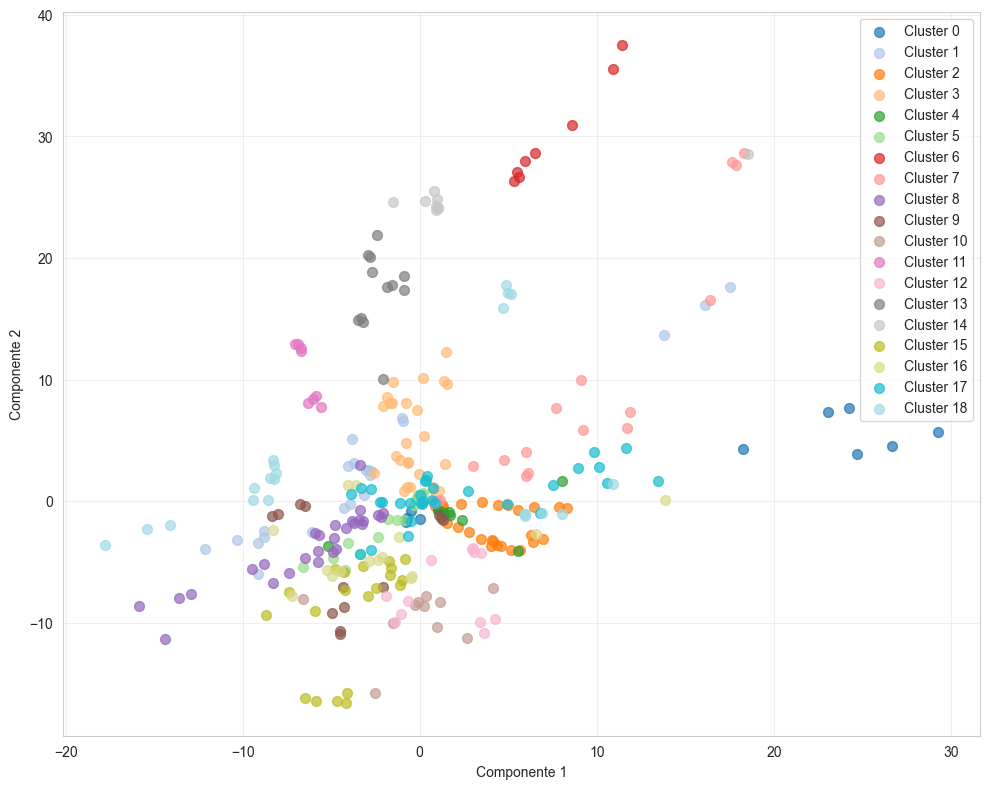

In [98]:
# reducimos a 2d usando PCA
best_assignments = gmm_results[19]["assignments"]
Z_2 = reducer_2d.encode(X_train_std, numpy=True)
plot_clusteres_2d(Z_2, best_assignments, xlabel="Componente 1", ylabel="Componente 2", filename="10_pca_2d")

In [99]:
analyze_cluster_homogeneity(best_assignments, y_train)

=== ANÁLISIS DE HOMOGENEIDAD DE CLUSTERS ===

Cluster 0  (10 muestras):
  Clase 7: 3 muestras (30.0%)
  Clase 9: 7 muestras (70.0%)
Cluster 1  (22 muestras):
  Clase 2: 2 muestras (9.1%)
  Clase 3: 3 muestras (13.6%)
  Clase 12: 1 muestras (4.5%)
  Clase 20: 6 muestras (27.3%)
  Clase 28: 5 muestras (22.7%)
  Clase 30: 2 muestras (9.1%)
  Clase 36: 3 muestras (13.6%)
Cluster 2  (29 muestras):
  Clase 1: 7 muestras (24.1%)
  Clase 10: 6 muestras (20.7%)
  Clase 18: 1 muestras (3.4%)
  Clase 26: 8 muestras (27.6%)
  Clase 31: 7 muestras (24.1%)
Cluster 3  (26 muestras):
  Clase 2: 1 muestras (3.8%)
  Clase 4: 1 muestras (3.8%)
  Clase 8: 2 muestras (7.7%)
  Clase 11: 3 muestras (11.5%)
  Clase 19: 3 muestras (11.5%)
  Clase 20: 1 muestras (3.8%)
  Clase 29: 8 muestras (30.8%)
  Clase 30: 2 muestras (7.7%)
  Clase 34: 2 muestras (7.7%)
  Clase 39: 3 muestras (11.5%)
Cluster 4  (9 muestras):
  Clase 10: 1 muestras (11.1%)
  Clase 27: 8 muestras (88.9%)
Cluster 5  (17 muestras):
  Clase 0: 

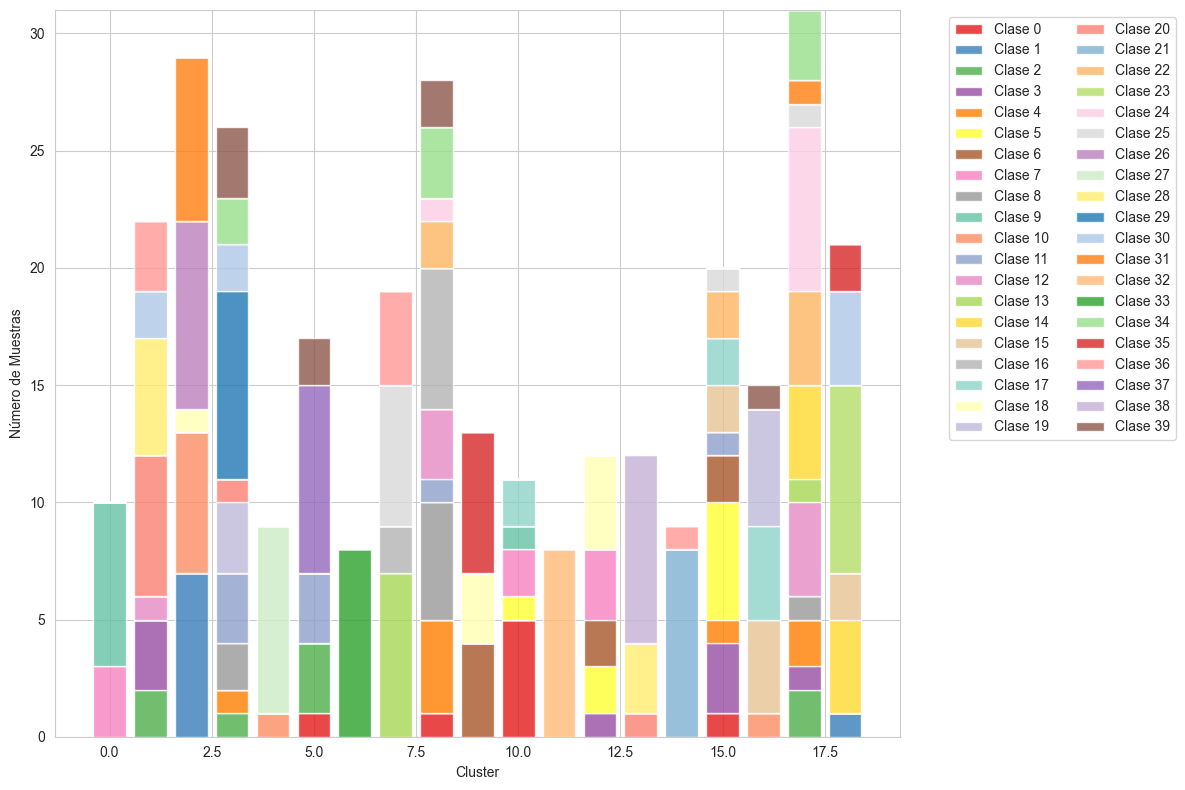

In [100]:
plot_cluster_composition(best_assignments, y_train, filename="11_cluster_composition")

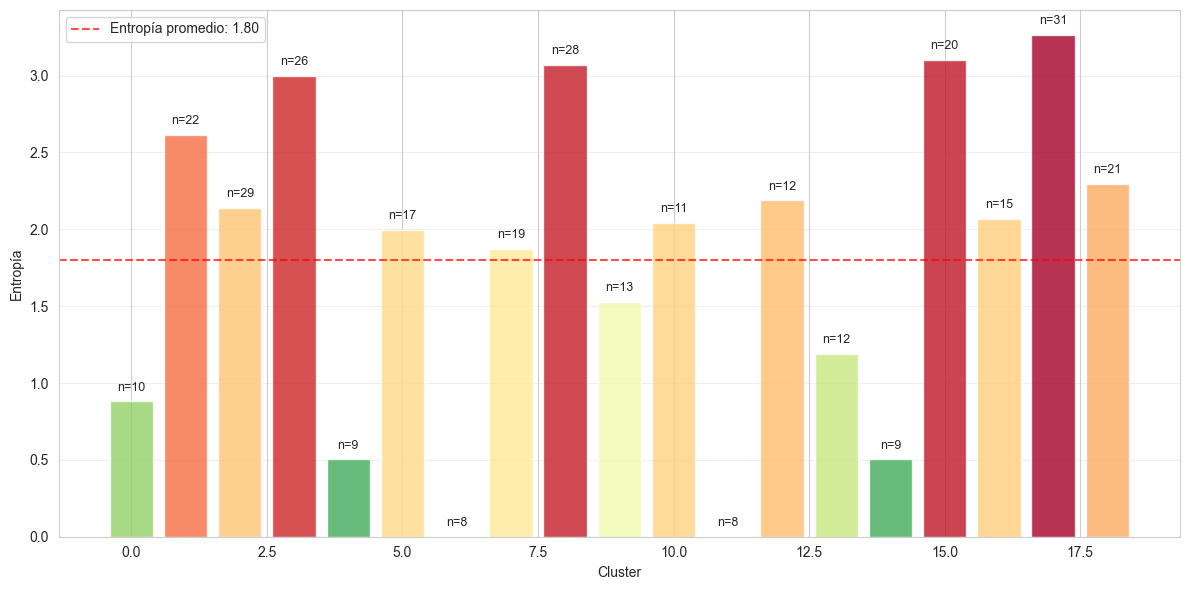

([np.float64(0.8812908989421536),
  np.float64(2.61265023203238),
  np.float64(2.140300169815418),
  np.float64(2.9979526972179973),
  np.float64(0.5032583344871068),
  np.float64(1.9986525461568192),
  np.float64(-1.4426951601859516e-10),
  np.float64(1.8710191203017619),
  np.float64(3.0705981176473847),
  np.float64(1.526234909516714),
  np.float64(2.040373392967149),
  np.float64(-1.4426951601859516e-10),
  np.float64(2.188721874819519),
  np.float64(1.1887218751080586),
  np.float64(0.5032583344871068),
  np.float64(3.1037016946146534),
  np.float64(2.0662478965913835),
  np.float64(3.263668181024457),
  np.float64(2.297079326675048)],
 [10, 22, 29, 26, 9, 17, 8, 19, 28, 13, 11, 8, 12, 12, 9, 20, 15, 31, 21])

In [101]:
plot_cluster_entropy(best_assignments, y_train, filename="12_cluster_entropy")

Experimento: samplear desde la distribución aprendida por GMM y pasar los samples por el decoder

In [102]:
def sample_from_gmm(means, covariances, priors, n_samples=1):
    samples = []

    for i in range(n_samples):
        component = np.random.choice(len(means), p=priors)
        sample = np.random.multivariate_normal(means[component], covariances[component])
        samples.append(sample)

    return np.array(samples)

samples_test = sample_from_gmm(gmm_results[19]["means"], gmm_results[19]["covariances"], gmm_results[19]["priors"], n_samples=5)

samples_test


array([[ 1.66342449e+00, -1.15221114e+01,  5.93124974e+00,
         1.20751392e+01, -4.63849599e-01,  2.28411401e+00,
         1.80764703e+01, -8.69888650e+00,  5.11090524e+00,
        -1.03726168e+01,  1.09504096e+01, -1.41654204e+01,
        -3.20143973e+00, -4.66960720e+00, -1.55090891e+01,
         4.67656357e+00, -5.43566058e+00, -3.26119930e+00,
         6.29235408e+00,  1.04900845e+01,  3.49847470e+00,
        -1.61621513e+01,  1.59387224e+01,  1.46763404e+01,
        -5.31990080e+00, -7.48660561e+00, -9.80139961e+00,
         1.97133884e+01,  6.55496098e+00, -7.84193728e+00,
         8.56391639e+00,  7.87324480e+00, -7.04742527e+00,
         2.74881030e+00,  1.16521205e+01,  7.82620306e+00,
         2.17765784e+00, -3.32525123e+00,  7.19508896e+00,
        -2.14541707e+01,  5.69380042e+00,  1.29140664e+01,
        -9.23169540e+00, -2.19641925e+00,  1.83647067e+00,
        -3.10345688e+00,  2.36613752e-01, -4.19218062e+00,
         1.37084767e+01, -2.14954568e+01, -1.55876847e+0

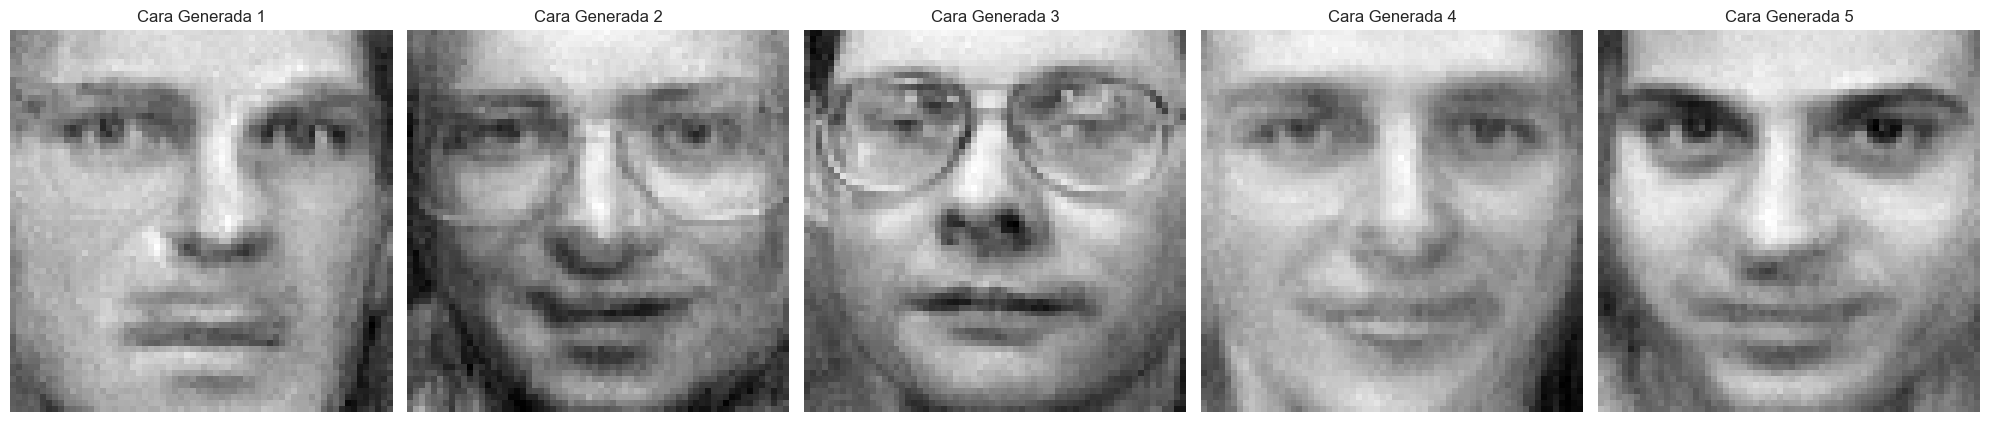

In [105]:

autoencoder.eval()
with torch.no_grad():
    decoded_samples = autoencoder.decode(samples_test, numpy=True) * X_train_sigma + X_train_mu

# Plotear
fig, axes = plt.subplots(1, 5, figsize=(20, 6))
for i in range(5):
    face = decoded_samples[i].reshape(64, 64)
    axes[i].imshow(face, cmap='gray')
    axes[i].set_title(f'Cara Generada {i+1}')
    axes[i].axis('off')
plt.tight_layout()
plt.show()